# Heart Disease Prediction - Modelling
### Objective:
- Train and evaluate multiple machine learning models to predict heart disease.
- Perform hyperparameter tuning to optimize model performance.
- Compare model performance using statistical tests to determine if differences are significant.
### Models to Train:
1. Logistic Regression (Baseline)
2. Logistic Regression with Feature Engineering
3. XGBoost Classifier
4. Random Forest Classifier

## 1. Imports and setup

In [9]:
# Standard Data Science Libraries
import numpy as np
import pandas as pd

# Utilities Libraries
from pathlib import Path
from itertools import combinations
import yaml
import os

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics Libraries
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

# Sklearn
from sklearn.model_selection import (
   StratifiedKFold, cross_val_score, RandomizedSearchCV, train_test_split
)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, classification_report

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Experiment tracking
import mlflow
import mlflow.sklearn
import mlflow.xgboost
from mlflow.tracking import MlflowClient

# Display settings
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Ensure reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Loading and preparing the data

In [ ]:
# Load the data
heart_data = pd.read_csv("./data/heart_disease_cleaned.csv")
heart_data.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,male,4,152,239,False,0,158,yes,3.6,2,2,7,Presence
1,1,52,male,1,125,325,False,2,171,no,0.0,1,0,3,Absence
2,2,56,female,2,160,188,False,2,151,no,0.0,1,0,3,Absence
3,3,44,female,3,134,229,False,2,150,no,1.0,2,0,3,Absence
4,4,58,male,4,140,234,False,2,125,yes,3.8,2,3,3,Presence


In [4]:
heart_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Age                      630000 non-null  int64  
 2   Sex                      630000 non-null  str    
 3   Chest pain type          630000 non-null  int64  
 4   BP                       630000 non-null  int64  
 5   Cholesterol              630000 non-null  int64  
 6   FBS over 120             630000 non-null  bool   
 7   EKG results              630000 non-null  int64  
 8   Max HR                   630000 non-null  int64  
 9   Exercise angina          630000 non-null  str    
 10  ST depression            630000 non-null  float64
 11  Slope of ST              630000 non-null  int64  
 12  Number of vessels fluro  630000 non-null  int64  
 13  Thallium                 630000 non-null  int64  
 14  Heart Disease  

In [5]:
# Transform categorical variables
categorical_cols = ['Sex', 'Chest pain type', 'FBS over 120', 'EKG results',
                    'Exercise angina', 'Slope of ST', 'Number of vessels fluro', 'Thallium', 'Heart Disease']

for col in categorical_cols:
    heart_data[col] = heart_data[col].astype('category')

categorical_features = categorical_cols[:-1]
numerical_features = [col for col in heart_data.columns if col not in categorical_cols and col != 'id']

In [6]:
# Split the data into features and target
X = heart_data.drop(['id', 'Heart Disease'], axis=1)
y = (heart_data['Heart Disease'] == "Presence").astype(int)
print(f"Shape of X: {X.shape}")
print(f"y value counts:\n{y.value_counts()}")

Shape of X: (630000, 13)
y value counts:
Heart Disease
0    347546
1    282454
Name: count, dtype: int64


In [7]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

## 3. Baseline model and evaluation

In [8]:
# Define a logistic regression pipeline and evaluate it using cross-validation
numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(drop='first')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

baseline_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(random_state=RANDOM_STATE))
])

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(baseline_pipeline, X_train, y_train, cv=cv, scoring='roc_auc')
print(f"Baseline Logistic Regression AUC-ROC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


Baseline Logistic Regression AUC-ROC: 0.9527 ± 0.0008


## 4. Basic feature engineering

In [9]:
# Create a new feature: Age group
def age_group(age):
    if age < 40:
        return 'Under 40'
    elif 40 <= age < 50:
        return '40-49'
    elif 50 <= age < 60:
        return '50-59'
    else:
        return '60 and above'

In [10]:
# Create a new feature: High cholesterol indicator
def high_cholesterol(cholesterol):
    return int(cholesterol > 240)

In [11]:
# Create a new feature: Age Cholesterol interaction
def age_cholesterol_interaction(age, cholesterol):
    return age * cholesterol

In [12]:
# Create a new feature: Blood Pressure Category
def bp_category(bp):
    if bp < 120:
        return 'Normal'
    elif 120 <= bp < 130:
        return 'Elevated'
    elif 130 <= bp < 140:
        return 'Hypertension Stage 1'
    else:
        return 'Hypertension Stage 2'

In [13]:
# Function to create all new features
def create_features(df):
    df['Age Group'] = df['Age'].apply(age_group)
    df['High Cholesterol'] = df['Cholesterol'].apply(high_cholesterol)
    df['Age_Cholesterol'] = df.apply(lambda row: age_cholesterol_interaction(row['Age'], row['Cholesterol']), axis=1)
    df['BP Category'] = df['BP'].apply(bp_category)
    return df

In [14]:
# Apply feature engineering to the training data
X_train_fe = X_train.copy()
X_train_fe = create_features(X_train_fe)
categorical_features_fe = categorical_features + ['Age Group', 'BP Category']
numerical_features_fe = numerical_features + ['Age_Cholesterol']
X_train_fe.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Age Group,High Cholesterol,Age_Cholesterol,BP Category
539041,48,male,4,140,249,False,2,144,no,2.5,2,1,7,40-49,1,11952,Hypertension Stage 2
211140,61,male,3,130,208,False,0,174,no,1.6,2,0,3,60 and above,0,12688,Hypertension Stage 1
325129,69,male,4,130,226,False,0,132,yes,1.4,2,0,6,60 and above,0,15594,Hypertension Stage 1
91177,67,male,4,140,269,False,2,182,yes,1.2,1,3,3,60 and above,1,18023,Hypertension Stage 2
346105,48,male,3,120,275,False,0,171,yes,0.4,1,0,3,40-49,1,13200,Elevated


### Four new features were created:
1. **Age Groups**: Categorizes age into groups (<40, 40-50, 50-60, >60).
2. **High Cholesterol Indicator**: A binary feature indicating whether cholesterol levels are above 240 mg/dL.
3. **Age-Cholesterol Interaction**: A feature created by multiplying age and cholesterol levels to capture potential interaction effects.
4. **Blood Pressure Categories**: Categorizes blood pressure into groups (<120, 120-129, 130-139, ≥140).

These features were created based on domain knowledge and exploratory data analysis, aiming to capture non-linear relationships and interactions that may improve model performance.

## 5. Evaluating the model with new features

In [15]:
# Define a pipeline for Logistic Regression with the new features and evaluate it using cross-validation
numerical_transformer_fe = StandardScaler()
categorical_transformer_fe = OneHotEncoder(drop='first')

preprocessor_fe = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer_fe, numerical_features_fe),
        ('cat', categorical_transformer_fe, categorical_features_fe)
    ]
)

logistic_pipeline = Pipeline([
    ('preprocessor', preprocessor_fe),
    ('model', LogisticRegression(random_state=RANDOM_STATE))
])

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
cv_scores_fe = cross_val_score(logistic_pipeline, X_train_fe, y_train, cv=cv, scoring='roc_auc')
print(f"Logistic Regression with Feature Engineering AUC-ROC: {cv_scores_fe.mean():.4f} ± {cv_scores_fe.std():.4f}")

Logistic Regression with Feature Engineering AUC-ROC: 0.9528 ± 0.0008


In [16]:
# Run paired Wilcoxon signed-rank test to compare the two models
stat, p_value = wilcoxon(cv_scores_fe, cv_scores)
print(f"Wilcoxon signed-rank test statistic: {stat:.4f}, p-value: {p_value:.4f}")
print(f"Mean AUC-ROC difference: {np.mean(cv_scores_fe - cv_scores):.4f}")

Wilcoxon signed-rank test statistic: 0.0000, p-value: 0.0020
Mean AUC-ROC difference: 0.0001


### 💡 Insight:
- All tough the model showed statistically significant improvement with the new features, the actual increase in AUC-ROC was modest. Given the low computational cost and interpretability of the engineered features, they were maintained in the final pipeline.

## 6. Experimenting with more complex models

In [5]:
# Get the root directory of the project
ROOT_DIR = Path.cwd().parent
print(f"Root directory: {ROOT_DIR}")

Root directory: c:\Users\biell\Documents\projects\potfolio\Predicting-Heart-Disease


In [6]:
# Basic Mlflow setup
mlflow.set_tracking_uri((ROOT_DIR / "mlruns").as_uri())
mlflow.set_experiment("Heart Disease Prediction - Model Selection")
mlflow.set_tag("project", "Heart Disease Prediction")
mlflow.set_tag("stage", "model_selection")


In [19]:
# Define candidate models for comparison
candidate_models = {
    'Logistic Regression': LogisticRegression(random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=50),
    'XGBoost': XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss')
}

In [20]:
mlflow.end_run()  # End any existing run before starting a new one

In [21]:
# Evaluate each candidate model using cross-validation
scores = {}
with mlflow.start_run(run_name="Baseline_Comparison"):
    for model_name, model in candidate_models.items():
        with mlflow.start_run(run_name=model_name, nested=True):
            pipeline = Pipeline([
                ('preprocessor', preprocessor_fe),
                ('model', model)
            ])
            cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
            cv_scores = cross_val_score(pipeline, X_train_fe, y_train, cv=cv, scoring='roc_auc')
            print(f"{model_name} AUC-ROC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

            mlflow.log_metric("cv_splits", len(cv_scores))
            mlflow.log_metric("mean_auc_roc", cv_scores.mean())
            mlflow.log_metric("std_auc_roc", cv_scores.std())

            scores[model_name] = cv_scores

Logistic Regression AUC-ROC: 0.9528 ± 0.0008
Random Forest AUC-ROC: 0.9451 ± 0.0009
XGBoost AUC-ROC: 0.9544 ± 0.0007


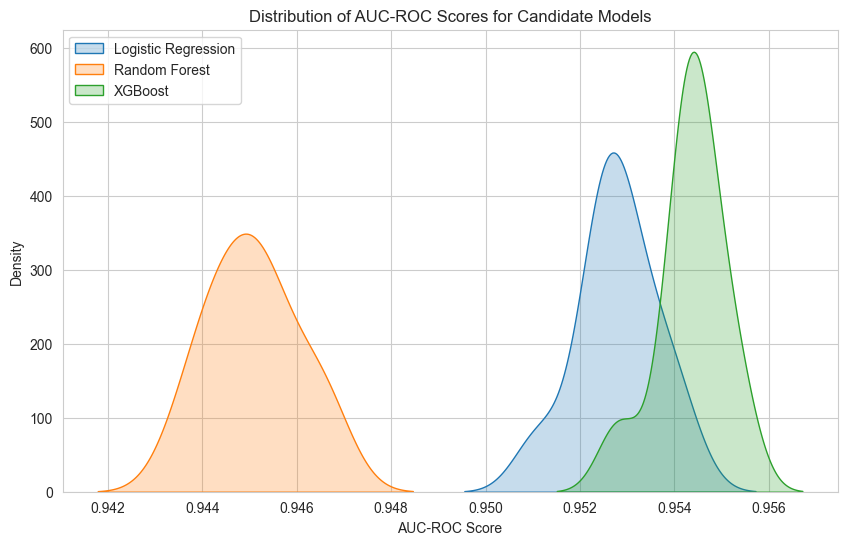

In [22]:
# Plot the distribution of AUC-ROC scores for each candidate model
plt.figure(figsize=(10, 6))
sns.set_style('whitegrid')
for model_name, cv_scores in scores.items():
    sns.kdeplot(cv_scores, label=model_name, fill=True)
plt.title("Distribution of AUC-ROC Scores for Candidate Models")
plt.xlabel("AUC-ROC Score")
plt.legend()
plt.show()

### 💡 Insight:
- Visually, the XGBoost and Logistic Regression models appear to have performed better than the Random Forest model, with the XGBoost model showing the highest AUC-ROC scores. However, we still need to perform statistical tests to confirm if these differences are significant.

In [23]:
# Evaluate statistical significance of differences between models using Wilcoxon signed-rank test
results = []
model_pairs = list(combinations(candidate_models.keys(), 2))
for model_a, model_b in model_pairs:
    stat, p_value = wilcoxon(scores[model_a], scores[model_b])
    results.append({
        'Model A': model_a,
        'Model B': model_b,
        'Wilcoxon Statistic': stat,
        'p-value': p_value,
        'mean_diff (A - B)': np.mean(scores[model_a] - scores[model_b])
    })

df_results = pd.DataFrame(results)
reject, pvals_corrected, _, _ = multipletests(df_results['p-value'], method='holm')
df_results['p_value_holm'] = pvals_corrected
df_results['reject_null'] = reject
df_results

,Model A,Model B,Wilcoxon Statistic,p-value,mean_diff (A - B),p_value_holm,reject_null
0,Logistic Regression,Random Forest,0.0,0.001953,0.007702,0.005859,True
1,Logistic Regression,XGBoost,0.0,0.001953,-0.001573,0.005859,True
2,Random Forest,XGBoost,0.0,0.001953,-0.009276,0.005859,True


### 💡 Insight:
- The Willcoxon signed-rank test results indicate that the the differences in AUC-ROC scores between the models are statistically significant, with p-values less than 0.05 for all pairwise comparisons.
- The mean differences as well as the visualization of the score distributions suggest that the XGBoost and Logistic Regression models outperform the Random Forest model, with XGBoost showing the highest performance.
- However, the choice between XGBoost and Logistic Regression may depend on other factors such as interpretability, computational resources, and specific use case requirements. Given the similar performance, Logistic Regression may be preferred for its simplicity and interpretability in a healthcare context.

## 7. Hyperparameter tuning

In [24]:
# Define possible hyperparameter values for tuning the Logistic Regression model
param_distributions = {
    "model__C": np.logspace(-4, 4, 20),
    "model__l1_ratio": np.linspace(0, 1, 2)
}

In [25]:
# Hyperparameter tuning for Logistic Regression using RandomizedSearchCV
# To save time, we will only do 10 iterations instead of 50,
# but in a real project we would want to do more extensive tuning to find the best hyperparameters for the model.
# Also, since we are doing hyperparameter tuning, we will use a smaller number of CV splits to speed up the process,
# but in a real project we would want to use more splits for a more robust evaluation.
with mlflow.start_run(run_name="LR_Hyperparameter_Tuning"):

    logistic_pipeline = Pipeline([
        ('preprocessor', preprocessor_fe),
        ('model', LogisticRegression(
            random_state=RANDOM_STATE,
            solver='saga'
        ))
    ])

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    random_search = RandomizedSearchCV(
        estimator=logistic_pipeline,
        param_distributions=param_distributions,
        n_iter=10,
        cv=cv,
        scoring='roc_auc',
        random_state=RANDOM_STATE,
        n_jobs=-1,
        return_train_score=True
    )

    random_search.fit(X_train_fe, y_train)

    best_params = random_search.best_params_
    best_score = random_search.best_score_
    best_std = random_search.cv_results_['std_test_score'][random_search.best_index_]


    # Log parameters
    mlflow.log_params(best_params)

    # Log CV metrics
    mlflow.log_metric("cv_mean_auc", best_score)
    mlflow.log_metric("cv_std_auc", best_std)

    # Log model artifact (candidate model)
    mlflow.sklearn.log_model(
        random_search.best_estimator_,
        artifact_path="candidate_model"
    )

2026/03/05 12:34:14 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\biell\AppData\Local\Temp\tmpksco1iu5\model\model.pkl, flavor: sklearn), fall back to return ['scikit-learn==1.8.0', 'cloudpickle==3.1.2']. Set logging level to DEBUG to see the full traceback.
2026/03/05 12:34:14 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


In [7]:
# Get best hyperparameters from the tuning run
client = MlflowClient()
best_run = client.search_runs(
    experiment_ids=[mlflow.get_experiment_by_name("Heart Disease Prediction - Model Selection").experiment_id],
    filter_string='tags.mlflow.runName = "LR_Hyperparameter_Tuning"',
    order_by=["metrics.cv_mean_auc DESC"],
    max_results=1
)[0]
best_params = {
    key.replace("model__", ""): value
    for key, value in best_run.data.params.items()
    if key.startswith("model__")
}

print(f"Best Hyperparameters from Tuning Run: {best_params}")

Best Hyperparameters from Tuning Run: {'C': '29.763514416313132', 'l1_ratio': '0.0'}


### 💡 Insight:
- We will proceed with Logistic Regression (with C=29.7635) as our final model due to its strong performance (very close to XGBoost), simplicity, and interpretability. The tuned hyperparameters will be saved for future reference and use in the final model training and evaluation on the test set.

In [11]:
# Save best params to a yaml file
target_path = ROOT_DIR / "config/model.yaml"
if not os.path.exists(target_path.parent):
    os.makedirs(target_path.parent)

with open(target_path, 'w') as file:
    yaml.dump(best_params, file)
    print(f"Best hyperparameters saved to {target_path}")

Best hyperparameters saved to c:\Users\biell\Documents\projects\potfolio\Predicting-Heart-Disease\config\model.yaml
